# 02 CIGNN EMNIST

> EMNIST letter exp

In [1]:
#| default_exp data

%load_ext autoreload
%autoreload 2

In [ ]:

import os
import pandas as pd
import sys
sys.path.append(os.path.abspath('..'))

import torch
from torchvision.transforms import ToTensor
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
from torchvision.io import read_image
import torch.nn as nn
import torch.optim as optim

from CIGNN_experimental.models.cnn.LeNet import LeNet


In [ ]:
# Define the transformation to convert PIL images to tensors
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Lambda(lambda x: torch.rot90(x, k=-1, dims=[1, 2])),  # Rotate 90 degrees 
    transforms.Lambda(lambda x: torch.flip(x, dims=[2]))  
])

# Load the EMNIST dataset (one test and one training set, using the "balanced" or "letters" split for example)
train_data = datasets.EMNIST(root="/data/datasets/HWR/emnist", split="letters", train=True, download=True, transform=transform)
train_dataloader = DataLoader(dataset=train_data, batch_size=8, shuffle=True)
test_data = datasets.EMNIST(root="/data/datasets/HWR/emnist", split="letters", train=False, download=True, transform=transform)
test_dataloader = DataLoader(dataset=test_data, batch_size=8, shuffle=True)

In [ ]:
# Now also try the Google implementation of LeNet 

from torchvision.models import GoogLeNet, GoogLeNet_Weights
googlenet = GoogLeNet(num_classes=26)

model = LeNet(1, 27)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# Training loop
num_epochs = 5  # Define the number of epochs
for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0
    for images, labels in train_dataloader:
        optimizer.zero_grad()  # Clear gradients
        outputs = model(images)  # Forward pass
        loss = criterion(outputs, labels)  # Calculate loss
        loss.backward()  # Backward pass
        optimizer.step()  # Update weights
        running_loss += loss.item()

    print(f"Epoch [{epoch+1}/{num_epochs}], Loss: {running_loss/len(train_dataloader):.4f}")

# Testing loop
model.eval()
correct = 0
total = 0
with torch.no_grad():
    for images, labels in test_dataloader:
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

accuracy = 100 * correct / total
print(f"Test Accuracy: {accuracy:.2f}%")

Epoch [1/5], Loss: 0.3306
Epoch [2/5], Loss: 0.1907
Epoch [3/5], Loss: 0.1547
Epoch [4/5], Loss: 0.1307
Epoch [5/5], Loss: 0.1149
Test Accuracy: 92.82%


In [ ]:
model_save_path = "lenet_emnist_letters.pth"
torch.save(model.state_dict(), model_save_path)

# To load the saved model
# model.load_state_dict(torch.load(model_save_path))
# model.eval()  # Set the model to evaluation mode

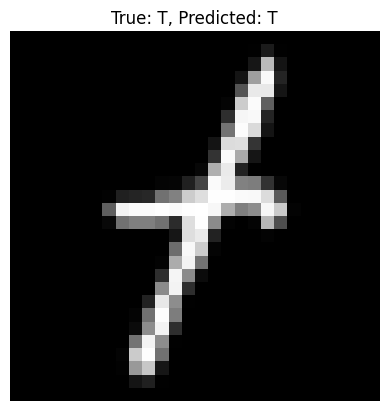

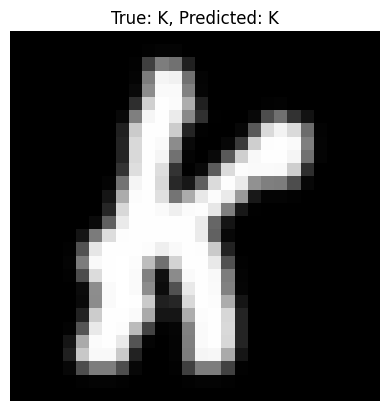

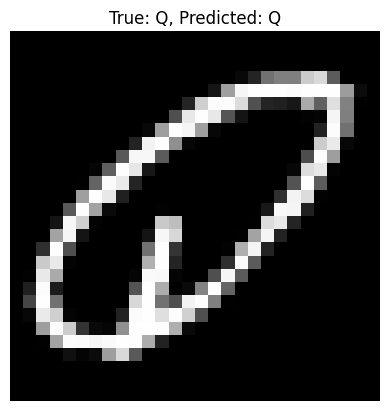

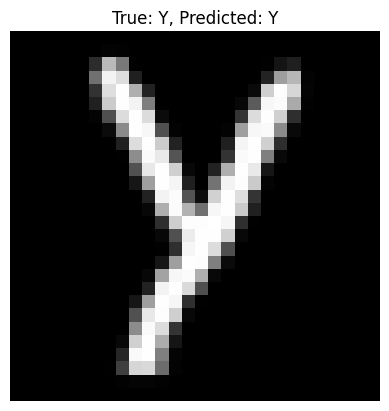

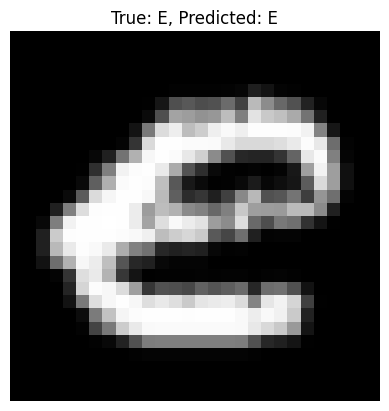

In [ ]:
import matplotlib.pyplot as plt
import torch

# Function to display an image and its labels
def show_sample(image, true_label, predicted_label):
    image = image.squeeze().numpy()  # Convert to 2D array for display
    plt.imshow(image, cmap='gray')
    plt.title(f"True: {chr(65 + true_label)}, Predicted: {chr(65 + predicted_label)}")  
    plt.axis('off')
    plt.show()

# Run inference and display samples
model.eval()
num_samples_to_show = 5
shown_samples = 0

with torch.no_grad():
    for images, labels in test_dataloader:
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)

        for i in range(len(images)):
            if shown_samples >= num_samples_to_show:
                break
            true_label = labels[i].item()
            predicted_label = predicted[i].item()
            # Shift by -1 to match a=1, ..., z=26 in EMNIST "letters"
            show_sample(images[i], true_label - 1, predicted_label - 1)
            shown_samples += 1
        
        if shown_samples >= num_samples_to_show:
            break

In [ ]:
embeddings = []
labels = []

model.eval()
with torch.no_grad():
    # Let us use the train_dataloader for now
    for images, lbls in train_dataloader:
    # for images, lbls in test_dataloader:
        # Do we even need the predicted class here? Unclear if we wanted to use the true
        # or predicted class for the clustering, ask Anna...
        pred_class, embedding = model(images, return_embedding=True)
        embeddings.append(embedding)
        labels.append(lbls)

# Concatenate all embeddings and labels
embeddings = torch.cat(embeddings)
labels = torch.cat(labels)

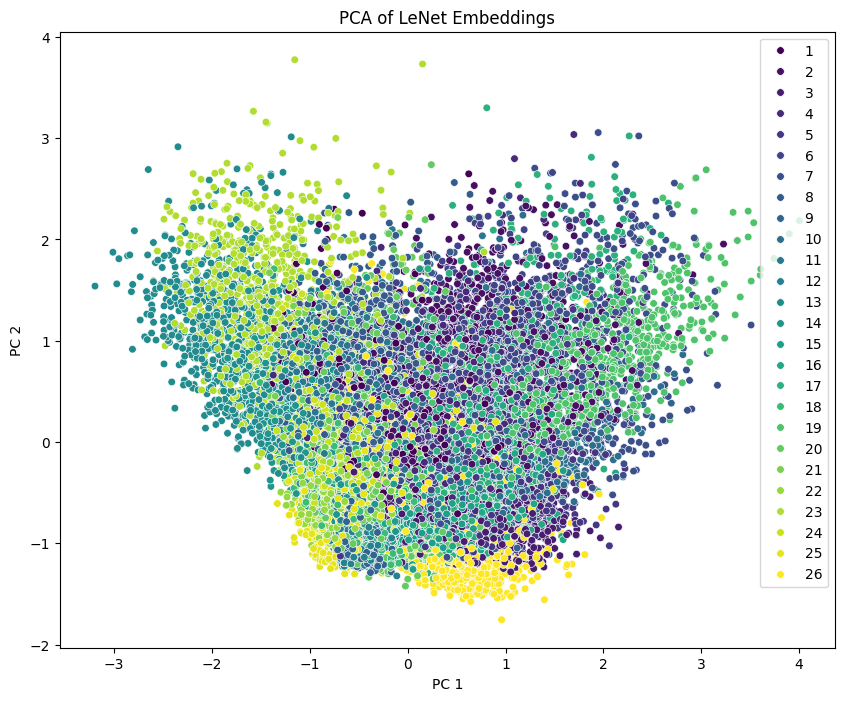

In [ ]:
embeddings_np = embeddings.view(embeddings.size(0), -1).numpy()
labels_np = labels.numpy()

# Now perform k-means clustering
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Perform k-means clustering
kmeans = KMeans(n_clusters=26, random_state=0).fit(embeddings_np)
cluster_labels = kmeans.labels_

# Visualize with PCA or t-SNE for dimensionality reduction
from sklearn.decomposition import PCA

pca = PCA(n_components=3)
reduced_embeddings = pca.fit_transform(embeddings_np)

# Plot the clusters
plt.figure(figsize=(10, 8))
sns.scatterplot(x=reduced_embeddings[:, 0], y=reduced_embeddings[:, 1], hue=labels_np, palette="viridis", legend="full", s=30)
plt.title("PCA of LeNet Embeddings")
plt.xlabel("PC 1")
plt.ylabel("PC 2")
plt.show()

In [ ]:
embeddings[0].size(1)


4

In [ ]:
num_classes = 26

mean_vectors = torch.zeros((num_classes, embeddings[0].size()))  # Shape: (num_classes, embedding_dim)
counts = torch.zeros(num_classes)  

# Accumulate embeddings for each class
for embedding, label in zip(embeddings, labels):
    class_index = label.item() - 1  # Adjust for 0-indexing
    mean_vectors[class_index] += embedding
    counts[class_index] += 1

# Calculate mean vectors
mean_vectors /= counts.unsqueeze(1)  # Avoid dividing by zero
mean_vectors_np = mean_vectors.numpy()

TypeError: zeros(): argument 'size' failed to unpack the object at pos 2 with error "type must be tuple of ints,but got tuple"

In [ ]:
#| hide
import nbdev; nbdev.nbdev_export()